# Part-A

### 1. Import Libraries 

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

In [33]:
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

### 2. Load and Understand the Data

In [3]:
df = pd.read_csv('customer_churn_data.csv')

In [4]:
# first_5_rows
df.head(5)

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [5]:
# last_5_rows
df.tail(5)

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [6]:
#number_of_rows_and_columns
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 1220
Number of Columns: 17


In [7]:
#column_names
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'tenure_months',
       'monthly_charges', 'total_charges', 'contract_type', 'internet_service',
       'tech_support', 'online_security', 'paperless_billing',
       'payment_method', 'num_support_calls', 'late_payments_last_year',
       'avg_monthly_usage_gb', 'churn'],
      dtype='object')

In [8]:
#data types
df.dtypes

customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

In [9]:
#dataset_info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   object 
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   object 
 3   region                   1220 non-null   object 
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   object 
 8   internet_service         1220 non-null   object 
 9   tech_support             1194 non-null   object 
 10  online_security          1199 non-null   object 
 11  paperless_billing        1220 non-null   object 
 12  payment_method           1200 non-null   object 
 13  num_support_calls        1220 non-null   int64  
 14  late_payments_last_year 

In [10]:
#descriptive_statistics
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
count,1220.000000,1220.000000,1198.000000,1187.000000,1220.000000,1220.000000,1196.000000
mean,49.309016,36.956557,66.509474,2421.133437,1.759836,1.143443,214.370569
std,18.125678,20.512560,24.295211,1681.896803,1.298902,1.078501,143.970148
min,18.000000,1.000000,18.000000,12.600000,0.000000,0.000000,0.000000
25%,34.000000,19.000000,50.047500,1011.740000,1.000000,0.000000,116.075000
50%,49.500000,38.000000,69.020000,2120.450000,2.000000,1.000000,206.300000
75%,65.000000,55.000000,86.465000,3619.765000,3.000000,2.000000,322.775000
max,80.000000,72.000000,118.580000,7579.280000,8.000000,6.000000,600.600000


### 3. Data Quality Check

In [16]:
#missing values in every column
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

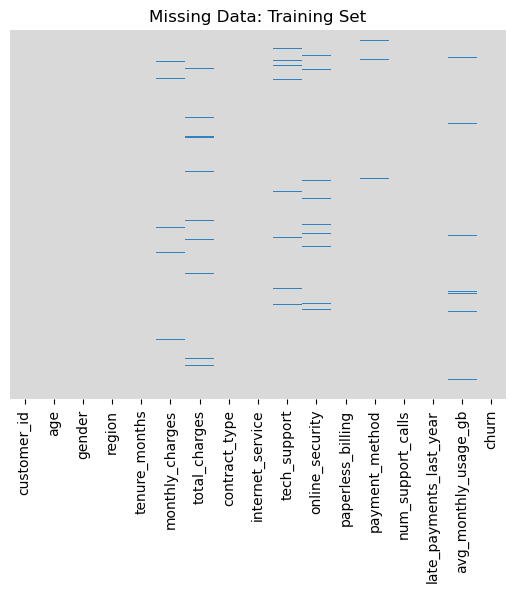

In [37]:
# Heatmap for missing values
sns.heatmap(df.isnull(),yticklabels = False, cbar = False,cmap = 'tab20c_r')
plt.title('Missing Data: Training Set')
plt.show()

In [20]:
#duplicate records
print(f"number of duplicated records: {df.duplicated().sum()}")

number of duplicated records: 20


In [21]:
#unique values categorical columns
##First identify categorical columns:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['customer_id', 'gender', 'region', 'contract_type', 'internet_service',
       'tech_support', 'online_security', 'paperless_billing',
       'payment_method', 'churn'],
      dtype='object')


In [23]:
#unique values
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


customer_id:
['CUST10001' 'CUST10002' 'CUST10003' ... 'CUST11198' 'CUST11199'
 'CUST11200']

gender:
['Female' 'Male']

region:
['East' 'West' 'North' 'South']

contract_type:
['Two year' 'One year' 'Month-to-month']

internet_service:
['DSL' 'Fiber optic' 'No']

tech_support:
['Yes' 'No' 'No internet service' nan]

online_security:
['Yes' 'No' 'No internet service' nan]

paperless_billing:
['No' 'Yes']

payment_method:
['Electronic check' 'Bank transfer' 'Credit card' 'Mailed check' nan]

churn:
['No' 'Yes']


In [27]:
#number of unique values
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique())


customer_id:
1200

gender:
2

region:
4

contract_type:
3

internet_service:
3

tech_support:
3

online_security:
3

paperless_billing:
2

payment_method:
4

churn:
2


In [26]:
#frequency of unique value:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


customer_id:
customer_id
CUST10460    2
CUST10142    2
CUST10831    2
CUST10695    2
CUST11129    2
            ..
CUST10405    1
CUST10404    1
CUST10403    1
CUST10402    1
CUST11200    1
Name: count, Length: 1200, dtype: int64

gender:
gender
Male      625
Female    595
Name: count, dtype: int64

region:
region
South    353
West     301
North    299
East     267
Name: count, dtype: int64

contract_type:
contract_type
Month-to-month    679
One year          306
Two year          235
Name: count, dtype: int64

internet_service:
internet_service
Fiber optic    563
DSL            460
No             197
Name: count, dtype: int64

tech_support:
tech_support
No                     582
Yes                    420
No internet service    192
Name: count, dtype: int64

online_security:
online_security
No                     539
Yes                    465
No internet service    195
Name: count, dtype: int64

paperless_billing:
paperless_billing
Yes    757
No     463
Name: count, dtype: int64

p

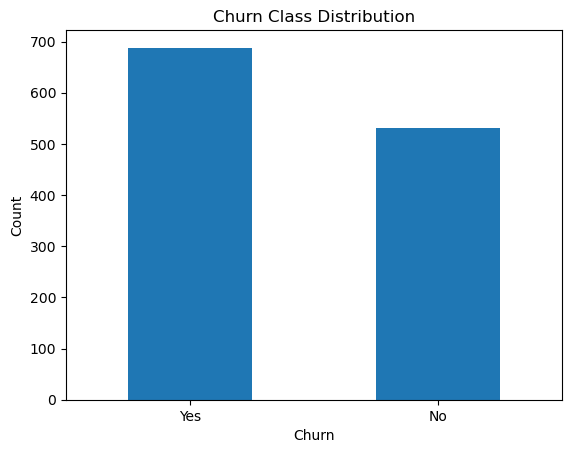

In [30]:
#class distribution of the churn target

df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keeps X-axis labels horizontal
plt.show()

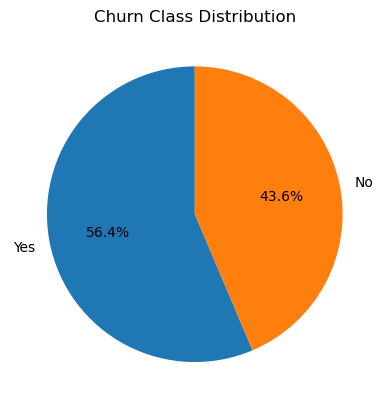

In [32]:
df['churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')  # Hides default y-label
plt.title('Churn Class Distribution')
plt.show()

### 4. Data Cleaning

In [40]:
# What to do with duplicate values?
df[df.duplicated()]

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1200,CUST10460,24,Male,North,18,70.54,1282.76,One year,DSL,No,Yes,Yes,Mailed check,1,0,233.4,No
1201,CUST10458,57,Female,West,21,64.33,1303.91,Two year,DSL,Yes,No,Yes,Electronic check,2,3,157.5,No
1202,CUST11023,72,Male,South,63,NaN,3028.05,Month-to-month,DSL,No,No,No,Electronic check,3,1,309.0,Yes
1203,CUST10142,31,Male,West,33,54.25,1767.61,Month-to-month,DSL,Yes,No,Yes,Mailed check,4,4,102.1,Yes
1204,CUST10669,75,Male,East,40,99.75,4002.50,Month-to-month,Fiber optic,No,Yes,Yes,Credit card,2,1,418.2,Yes
1205,CUST11012,68,Female,South,47,57.40,2738.47,Month-to-month,DSL,No,Yes,No,Bank transfer,3,0,165.2,No
1206,CUST10152,35,Male,West,4,44.48,107.38,One year,DSL,No,No,Yes,Electronic check,2,0,125.7,Yes
1207,CUST10831,33,Female,North,35,66.28,2385.27,Month-to-month,DSL,No,Yes,No,Credit card,2,2,184.7,Yes
1208,CUST10751,78,Female,West,44,39.43,1783.32,Month-to-month,DSL,Yes,Yes,No,Electronic check,1,0,143.1,No
1209,CUST10047,46,Female,East,61,27.18,1543.92,Month-to-month,No,No internet service,No internet service,No,Electronic check,3,1,0.0,No


In [41]:
df = df.drop_duplicates()

### Handling Duplicate Records

I checked the dataset for duplicate records using `duplicated().sum()`.

Exact duplicate records were removed because they represent repeated copies of the same observation rather than new information. Keeping duplicate records could cause certain observations to receive more weight during model training and potentially affect the model's performance.

Therefore, duplicate records were removed using `drop_duplicates()`.

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
# how to handle missing numeric values?

numeric_cols = ['monthly_charges', 'total_charges', 'avg_monthly_usage_gb']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1200 non-null   object 
 1   age                      1200 non-null   int64  
 2   gender                   1200 non-null   object 
 3   region                   1200 non-null   object 
 4   tenure_months            1200 non-null   int64  
 5   monthly_charges          1200 non-null   float64
 6   total_charges            1200 non-null   float64
 7   contract_type            1200 non-null   object 
 8   internet_service         1200 non-null   object 
 9   tech_support             1174 non-null   object 
 10  online_security          1179 non-null   object 
 11  paperless_billing        1200 non-null   object 
 12  payment_method           1181 non-null   object 
 13  num_support_calls        1200 non-null   int64  
 14  late_payments_last_year  1200

### Handling Missing Numeric Values

The columns `monthly_charges`, `total_charges`, and `avg_monthly_usage_gb` contain missing values. Since these are numerical variables and the proportion of missing values is relatively small, the missing values were imputed using the median of each respective column.

Median imputation was chosen because the median is less sensitive to extreme values and outliers than the mean. This allows us to retain the affected customer records without introducing substantial distortion to the numerical variables.


In [45]:
# how to handle missing categorical values

categorical_cols = ['tech_support', 'online_security', 'payment_method']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1200 non-null   object 
 1   age                      1200 non-null   int64  
 2   gender                   1200 non-null   object 
 3   region                   1200 non-null   object 
 4   tenure_months            1200 non-null   int64  
 5   monthly_charges          1200 non-null   float64
 6   total_charges            1200 non-null   float64
 7   contract_type            1200 non-null   object 
 8   internet_service         1200 non-null   object 
 9   tech_support             1200 non-null   object 
 10  online_security          1200 non-null   object 
 11  paperless_billing        1200 non-null   object 
 12  payment_method           1200 non-null   object 
 13  num_support_calls        1200 non-null   int64  
 14  late_payments_last_year  1200

### Handling Missing Categorical Values

The categorical columns `tech_support`, `online_security`, and `payment_method` contain a small number of missing values.

The missing values were replaced using **mode imputation**, where each missing value is replaced by the most frequently occurring category within its respective column.

Mode imputation was selected because these variables are categorical and the proportion of missing values is relatively small. This approach allows us to retain all customer records while using the most common category as a reasonable replacement for missing observations.


In [47]:
# whether customer_id should be used for model training or removed

df = df.drop(columns=['customer_id'])

### Handling Customer ID

`customer_id` was excluded from model training because it is an identifier rather than a meaningful predictive feature.

The ID does not represent a customer's characteristics or behavior. Including it could introduce meaningless patterns into the model and potentially reduce its ability to generalize to unseen customers.

Therefore, `customer_id` was removed from the feature set before model training.

### 5. Exploratory Data Analysis

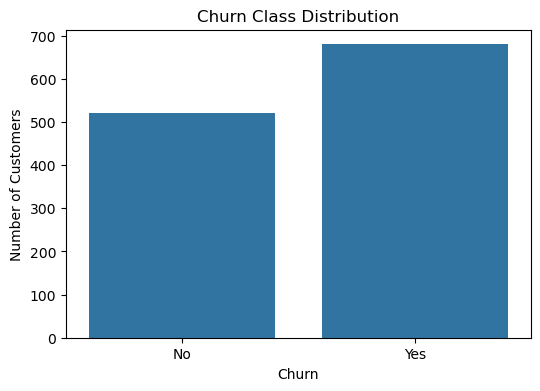

In [49]:
# Churn Class Distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn')

plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The churn distribution shows the number of customers who churned compared with those who remained. This helps identify whether the target variable is balanced or imbalanced, which is important when selecting and evaluating a classification model.
The dataset contains more churned customers than non-churned customers, indicating a slightly class imbalance.

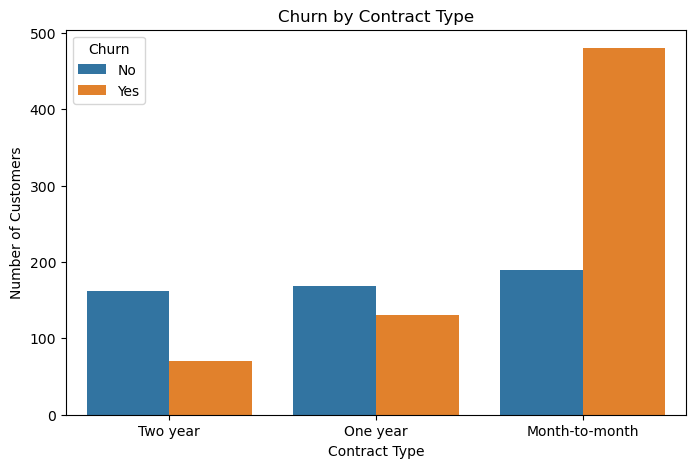

In [50]:
# Churn by Contract Type

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contract_type', hue='churn')

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Observation

Churn varies across different contract types. The visualization allows us to identify which contract categories have relatively higher or lower churn.

The differences suggest that contract type may be an important feature for predicting customer churn.

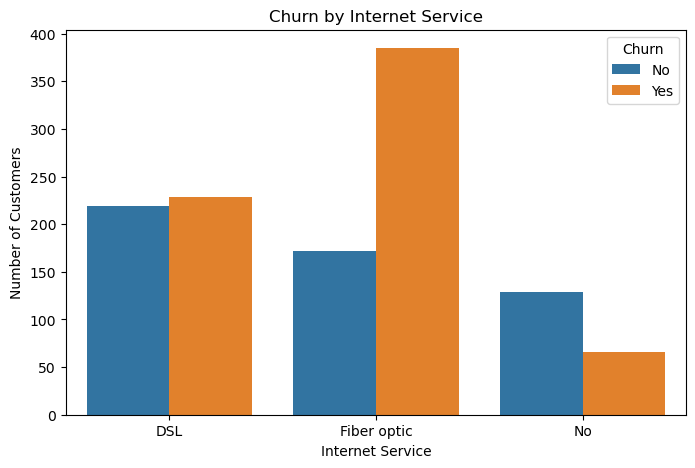

In [53]:
# Churn by Internet Service

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='internet_service', hue='churn')

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Observation

The distribution of churn differs across internet service categories. Some internet service groups have a larger proportion of churned customers than others.

This suggests that internet service type may have a relationship with customer churn and could be useful as a predictive feature.

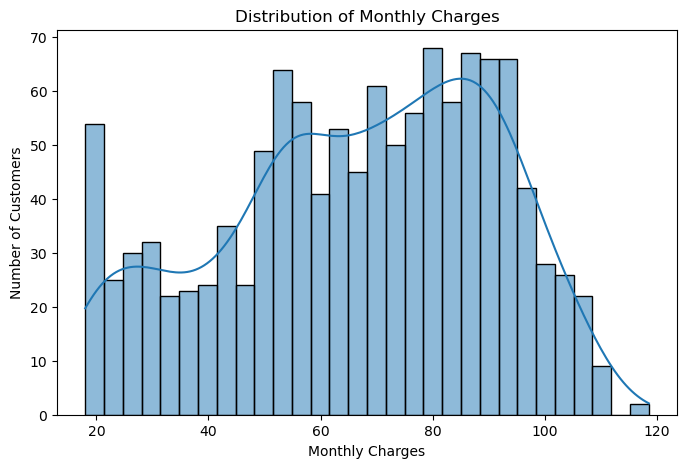

In [59]:
# monthly charges distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='monthly_charges',
    bins=30,
    kde=True
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

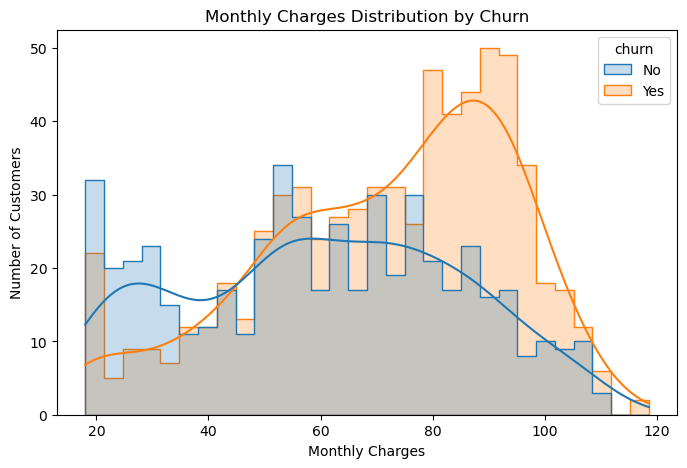

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='monthly_charges',
    hue='churn',
    bins=30,
    kde=True,
    element='step'
)

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

### Observation

Monthly charges show the distribution of the amount customers pay each month. The distribution can help identify whether charges are concentrated within a particular range or whether there are unusually high or low values.

Comparing the distributions by churn status can also indicate whether customers with different monthly charges have different churn patterns.

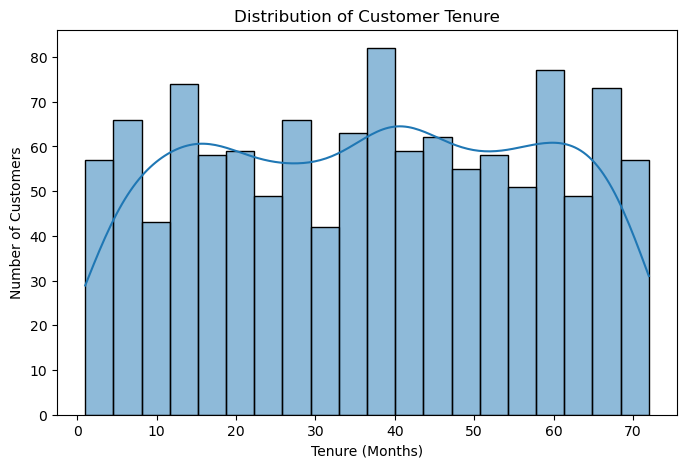

In [60]:
# tenure distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure_months',
    bins=20,
    kde=True
)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

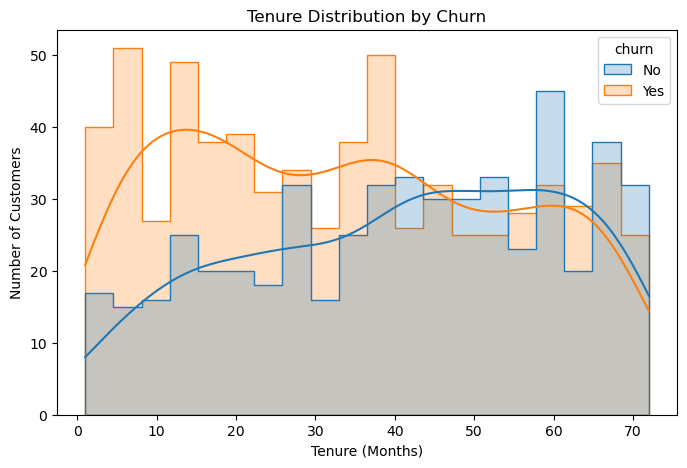

In [61]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure_months',
    hue='churn',
    bins=20,
    kde=True,
    element='step'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Observation

The tenure distribution shows how long customers have been associated with the company. The distribution can indicate whether the dataset contains more newer or longer-term customers.

Comparing tenure across churn groups can help identify whether customer retention is associated with the length of the customer relationship.

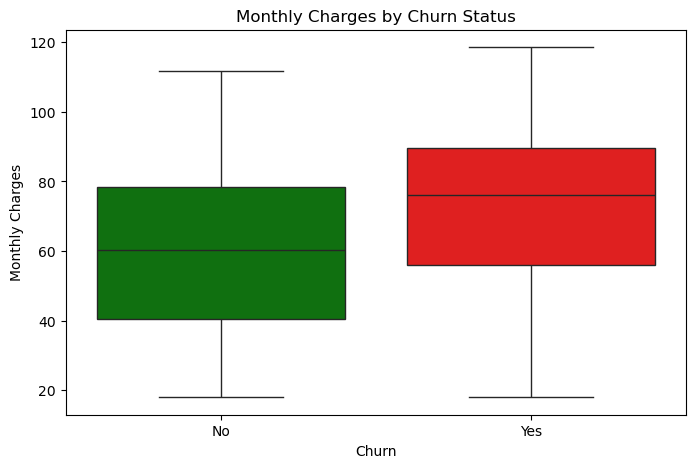

In [64]:
# Monthly Charges by Churn Status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='churn',
    y='monthly_charges',
    hue='churn',
    palette={'Yes': 'red', 'No': 'green'}
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Observation

The box plot compares the distribution of monthly charges between churned and non-churned customers.

Differences in the median and overall distribution of monthly charges between the two groups may indicate that monthly charges have a relationship with customer churn.

The median monthly charge for churned customers is around 76, whereas for retained customers, it is around 60.

The middle 50% of retained customers pay between approximately 40 and 78 per month.
The middle 50% of churned customers pay between approximately 56 and 90 per month.

Non-Churned Customers' Charges range from roughly 18 to 112.
Churned Customers' Charges extend higher, ranging from roughly 18 up to nearly 118.

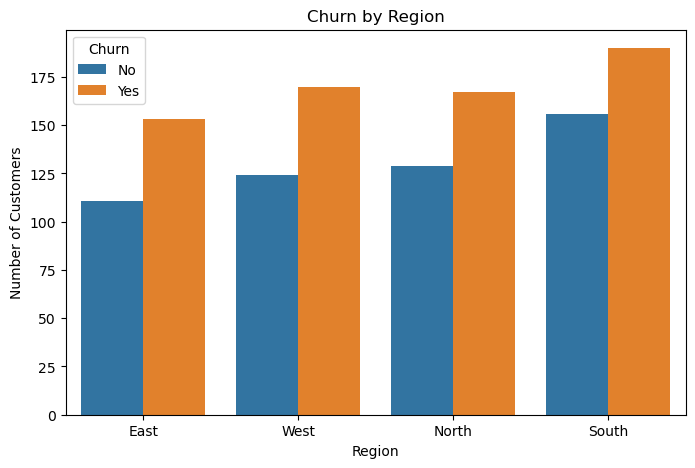

In [88]:
# Churn by Region

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='region', hue='churn')

plt.title('Churn by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### 6. Prepare Features and Target

In [66]:
# Create input features and target
X = df.drop(columns=['churn'])
y = df['churn']

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

X shape: (1200, 15)
y shape: (1200,)

Numeric columns:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']

Categorical columns:
['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']


### 7. Train-Test Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (960, 15)
Testing set: (240, 15)


### Train-Test Split

The cleaned dataset was divided into **training and testing sets** using an 80:20 ratio. 
**80% of the data** was used for training the machine-learning model, while the remaining **20%** was reserved for evaluating its performance.

A fixed `random_state=42` was used to ensure that the same data split can be reproduced. 
`stratify=y` was also applied to maintain a similar proportion of churn and non-churn customers in both the training and testing sets.


### 8. Preprocessing

In [74]:
# Numeric pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

### Data Preprocessing

A `ColumnTransformer` was used to create a preprocessing pipeline for the mixed numerical and categorical data.

For **numeric features**, missing values were replaced using the **median**, followed by `StandardScaler` to standardize the numerical variables.

For **categorical features**, missing values were replaced using the **most frequent category (mode)**. The categorical variables were then converted into numerical form using **One-Hot Encoding**. The `handle_unknown='ignore'` option ensures that previously unseen categories in the test data do not cause errors.

In [75]:
# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (960, 31)
Processed testing shape: (240, 31)


The preprocessing pipeline was fitted only on the training data and then applied to both the training and testing sets. This prevents information from the test set from leaking into the model during training.

### 9. Train At Least TWO Models

In [76]:
# Logistic Regression
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [77]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Train Random Forest
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [78]:
y_pred_lr = logistic_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

### 10. Model Evaluation

In [79]:
print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label='Yes'))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label='Yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression =====
Accuracy : 0.7583333333333333
Precision: 0.7671232876712328
Recall   : 0.8235294117647058
F1 Score : 0.7943262411347518

Confusion Matrix:
[[ 70  34]
 [ 24 112]]

Classification Report:
              precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240



In [80]:
print("===== Random Forest =====")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Yes'))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label='Yes'))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label='Yes'))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy : 0.7166666666666667
Precision: 0.7428571428571429
Recall   : 0.7647058823529411
F1 Score : 0.7536231884057971

Confusion Matrix:
[[ 68  36]
 [ 32 104]]

Classification Report:
              precision    recall  f1-score   support

          No       0.68      0.65      0.67       104
         Yes       0.74      0.76      0.75       136

    accuracy                           0.72       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.72      0.72      0.72       240



In [81]:
# Create a comparison table of the models.
results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, pos_label='Yes'),
        precision_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, pos_label='Yes'),
        recall_score(y_test, y_pred_rf, pos_label='Yes')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr, pos_label='Yes'),
        f1_score(y_test, y_pred_rf, pos_label='Yes')
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.758333,0.767123,0.823529,0.794326
1,Random Forest,0.716667,0.742857,0.764706,0.753623


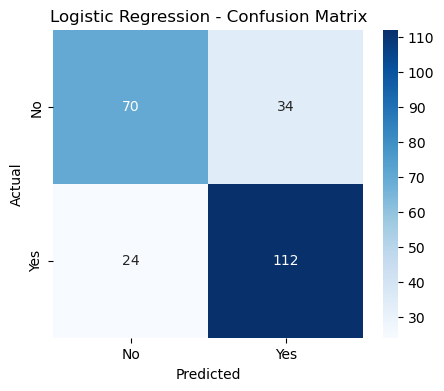

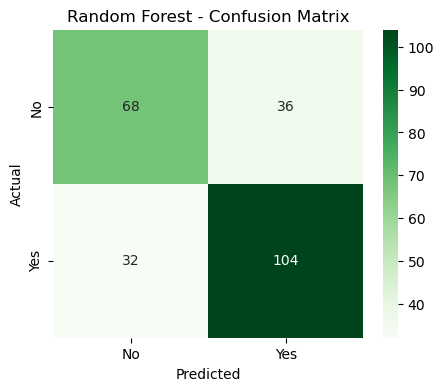

In [82]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 11. Select the Final Model

### Final Model Selection

Based on the evaluation results on the unseen test set, **Logistic Regression was selected as the final model**.

Logistic Regression achieved better performance than Random Forest across all four main evaluation metrics. It achieved an **accuracy of 75.83%**, **precision of 76.71%**, **recall of 82.35%**, and an **F1 Score of 79.43%**. In comparison, Random Forest achieved an accuracy of 71.67%, precision of 74.29%, recall of 76.47%, and an F1 Score of 75.36%.

For this churn prediction problem, recall is particularly important because it measures how effectively the model identifies customers who actually churn. Logistic Regression correctly identified **112 out of 136 churned customers**, resulting in a recall of **82.35%**, while Random Forest correctly identified **104 out of 136** churned customers.

Therefore, Logistic Regression was selected because it provided better overall test-set performance and was more effective at identifying customers who churned. The selection was based on multiple evaluation metrics rather than accuracy alone.


### 12. Save the Final Model

In [84]:
joblib.dump(logistic_model, 'churn_pipeline.pkl')

print("Pipeline saved successfully!")

Pipeline saved successfully!


### 13. Reload and Test the Saved Model

In [85]:
loaded_pipeline = joblib.load('churn_pipeline.pkl')

y_pred = loaded_pipeline.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7583333333333333


In [87]:
import sklearn
print(sklearn.__version__)

1.7.2
